## Supervised Learning - Logistic Regression - Predicting Heart Disease Risk Scores 
### Risk-prediction and early-warning tools for clinical cohorts
This project aims to develop a classification model that scores heart disease risk based on eleven clinical features, enabling prioritized interventions amid cost barriers. 

### Code Attribution 
<ul>
  <li> Title: Machine Learning with Python Cookbook 
  <li> Author: Kyle Gallatin & Chris Albon
  <li> Date: 8 March 2026
  <li> Modified By: Charlotte Alley
  <li> Description: Data preparation, model selection and evaluation

<ul>
  <li> Title: LogisticRegression 
  <li> Author: scikit-learn.org
  <li> Date: 8 March 2026
  <li> Modified By: Charlotte Alley
  <li> Description: This class implements regularized logistic regression using a set of available solvers.

<ul>
  <li> Title: Donut Chart using Matplotlib in Python
  <li> Author: GeeksforGeeks
  <li> Date: 8 March 2026
  <li> Modified By: Charlotte Alley
  <li> Description: Donut charts are the modified version of a pie chart with the area of center cut out.

### Setup

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from ydata_profiling import ProfileReport
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from scipy.stats import randint, uniform
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score, f1_score
from matplotlib.lines import Line2D
from matplotlib.patches import Circle

In [2]:
# Reads in data
heart_df = pd.read_csv("heart.csv")

In [3]:
# Checks to make sure read was successful
heart_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
# No missing values, blend of data types
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
# Creates variable report for data understanding
profile = ProfileReport(heart_df, title = "Heart Failure Prediction Report")

In [6]:
# Outputs report to a file to be read in seperate window, for easier 
# manipulation
profile.to_file("report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 19607.19it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Data Understanding - Variable Report
The correlation matrix showed a strong linear relationship between two of the 12 features and the target variable, an early indicator that a predictive signal was likely present. There were also many weak-to-moderate positive correlations among the features, suggesting some multicollinearity and redundancy. Most histogram distributions of numerical variables were relatively normal, and only a couple required normalization for the models that aren’t robust to skew: Logistic Regression and SVC. There weren’t any alerts for high cardinality in the categorical variables, making one-hot-encoding an excellent option. The bar plots showed that many categorical features were imbalanced, while the target variable was relatively balanced, making SMOTE unnecessary. The numerical variables ranged widely in magnitude and required Min-Max scaling for model preparation.

### Attribute Information as Provided by Kaggle
Age: Numeric: age of the patient [years]

Sex: Binary Categorical: Imbalanced Feature: sex of the patient [M: Male, F: Female]

ChestPainType: Categorical: Imbalanced Feature: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]

RestingBP: Numerical: resting blood pressure [mm Hg]

Cholesterol: Numerical: Needs Imputation or removal for zeros: serum cholesterol [mm/dl]

FastingBS: Binary Categorical: Imbalanced Feature: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]

RestingECG: Categorical: Imbalanced Feature: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]

MaxHR: Numerical: maximum heart rate achieved [Numeric value between 60 and 202]

ExerciseAngina: Categorical: exercise-induced angina [Y: Yes, N: No]

Oldpeak: Numerical: oldpeak = ST [Numeric value measured in depression], Oldpeak quantifies ST segment depression observed during peak exercise on an ECG, measured in millimeters (mm) of depression from baseline—higher values (typically >1 mm) signal greater myocardial ischemia from stress-induced oxygen demand mismatch. (https://emergencymedicinecases.com/ecg-cases-st-depressed-mnemonic-occlusion-mi/) 

ST_Slope: Categorical: Imbalanced Feature: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping], This describes the ST segment's trajectory post-exercise: Upsloping (normal response, low risk), Flat (equivocal, possible mild ischemia), Downsloping (strongly ischemic, high heart disease risk). (https://litfl.com/st-segment-ecg-library/)

HeartDisease: Boolean: output class [1: heart disease, 0: Normal]

## Data Preparation
The variable report on the dataset showed an alert indicating two variables with high proportions of zeroes: Cholesterol and Oldpeak. For Oldpeak, the zero values are meaningful and should be kept, but a cholesterol value of zero is clinically impossible, so I decided to impute the values for that feature with the median cholesterol value, since they were likely recording errors. Although the variable report didn’t show an alert for high skew in Cholesterol and Oldpeak, I noticed that they had higher Skewness values than the other variables (-.61 for Cholesterol and 1.02 for Oldpeak). After imputing the median for Cholesterol, the new Skewness value was 0.01. For Oldpeak, I used the Yeo-Johnson method, which accounts for both zero and negative values, with PowerTransformer to reduce the Skewness value to -.30.  With the zero values and skew handled, I used MinMaxScaler to scale the numerical features. This scaling sets the minimum to zero and the maximum to one, directly complementing the one-hot encoding of the categorical variables and providing the models with tidy features on the same scale. After using OneHotEncoder on the categorical variables, the data was ready to be split into training and testing data. I originally planned to split using stratified sampling based on the features, since many features had low cardinality and high imbalance, but decided to use stratified sampling based on the target variable for simplicity. 

### Imputing zeros in Cholesterol 
It's not humanly possible to have a cholesterol of zero, and since it's not likely they included zombies in the dataset, I decided to impute the zeros with the median. The imputation also corrected the skew, with a new value of 0.01 post-imputation. 

In [7]:
# Imputes zero values with median of non-zero values
heart_df['Cholesterol'] = heart_df['Cholesterol'].replace(
    0, heart_df[heart_df['Cholesterol'] > 0]['Cholesterol'].median())

### Fixing Skew on Oldpeak
When I went to fix the skew on Oldpeak, I realized that there are also negative values for this variable, which are still meaningful. I used Yeo-Johnson to fix the skew for the SVC and Logistic Regression models, as it can handle both negative and zero values. After the transformation, the skewness values were well below 0.5 or above -0.5 (compared to the 1.022 in Oldpeak before the transformation). 

In [8]:
# Sets standardize to False because will use MinMaxScaler later in pipeline
transformer = PowerTransformer(method='yeo-johnson', standardize=False)

# Uses double brackets for 2D dataframe, ravel() flattens 2D back to 1D
heart_df['Oldpeak'] = transformer.fit_transform(heart_df[['Oldpeak']]).ravel()

In [9]:
# Creates another report to view changes
profile = ProfileReport(heart_df, title="Fixed Skew")

In [10]:
profile.to_file("report2.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 75573.05it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### Scaling Numeric Variables
Scaling the numeric variables with a minimum of zero and a maximum of one will create tidy features alongside the one-hot-encoded categorical variables. 

In [11]:
# Initiates scaler, stores categorical columns, transforms cols
scaler = MinMaxScaler()
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
heart_df[cols] = scaler.fit_transform(heart_df[cols])

In [12]:
# Shows that all scaling has been conducted, with mins at 0 and maxs at 1
heart_df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,0.520630,0.661983,0.305415,0.233115,0.540911,0.701711,0.553377
std,0.192502,0.092571,0.103091,0.423046,0.179298,0.093753,0.497414
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.387755,0.600000,0.249035,0.000000,0.422535,0.621934,0.000000
50%,0.530612,0.650000,0.293436,0.000000,0.549296,0.691619,1.000000
75%,0.653061,0.700000,0.351351,0.000000,0.676056,0.768215,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### One-Hot-Encode Categoricals
I'm always suprised by how easy this is. Hopefully I didn't jinx it.

In [13]:
# Drops first to avoid multicollinearity
encoder = OneHotEncoder(sparse_output=False, drop='first')
cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 
        'ST_Slope']
encoded = encoder.fit_transform(heart_df[cols])

# Converts to dataframe with proper names instead of directly assigning back
encoded_df = pd.DataFrame(encoded, 
                          columns=encoder.get_feature_names_out(cols), 
                          index=heart_df.index)

# Drops original categorical columns, adds new one-hot-encoded columns
heart_df = heart_df.drop(cols, axis=1).join(encoded_df)

# Shows new columns 
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    float64
 1   RestingBP          918 non-null    float64
 2   Cholesterol        918 non-null    float64
 3   MaxHR              918 non-null    float64
 4   Oldpeak            918 non-null    float64
 5   HeartDisease       918 non-null    int64  
 6   Sex_M              918 non-null    float64
 7   ChestPainType_ATA  918 non-null    float64
 8   ChestPainType_NAP  918 non-null    float64
 9   ChestPainType_TA   918 non-null    float64
 10  FastingBS_1        918 non-null    float64
 11  RestingECG_Normal  918 non-null    float64
 12  RestingECG_ST      918 non-null    float64
 13  ExerciseAngina_Y   918 non-null    float64
 14  ST_Slope_Flat      918 non-null    float64
 15  ST_Slope_Up        918 non-null    float64
dtypes: float64(15), int64(1)
m

### Stratified Sample for Imbalanced Features
I tried to stratify using the imbalanced features, but it didn't work out. I decided to stratify using the target variable, and hopefully the cross-validation used in the RandomizedSearchCV will make up for the imbalanced features to reduce bias and overfitting. 

In [14]:
# Isolates target variable 
X = heart_df.drop('HeartDisease', axis=1)
y = heart_df['HeartDisease']

# Splits data into stratified 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y,test_size=0.2, random_state=0)

### Selecting Best Model with Randomized Search
Since the plan was to use RandomizedSearchCV, I began by creating a dictionary for each potential model that specifies parameters to produce a predicted probability. Then I created a second dictionary for potential hyperparameters for each model and commonly used ranges. After specifying the scoring metric as the previously mentioned neg_brier_score metric, 5-fold cross-validation, and 30 iterations, the RandomizedSearchCV was ready to run and store the best model and its results. 
	The chosen number of iterations struck a nice balance between time, computational effort, and effectiveness. Fitting 5 folds for each of the 30 iterations totaled 150 fits for each model, which my computer handled with minimal fuss in about a minute. XGBoost was the winning model, with a CV Average of -.1062 and a holdout Average of -0.0863. When using neg_brier_score as the scoring metric to choose a model, which maximizes predicted probability accuracy, you’re looking for the value that is closest to 0, which would be a perfect model. Both the CV Average, which is the model’s average Brier score across 5-fold cross-validation on training data, and the Holdout Average, which is the average Brier score on unseen test data, are the closest to zero of any model attempted with the XGBoost. XGBoost is a boosting ensemble model that aims to reduce bias and learns from mistakes made in each previous iteration. The hyperparameters chosen for the XGBoost also specify a maximum depth of 4 nodes, which encourages speed and interpretability. 

In [15]:
# Defines models to choose from, Probability = True and logloss enables 
# predict_proba() for prediction scores
models = {'XGBoost': XGBClassifier(eval_metric='logloss', random_state=0), 
          'SVC': SVC(probability=True, random_state=0), 
          'Random Forest': RandomForestClassifier(random_state=0), 
          'Logistic Regression': LogisticRegression(max_iter=1000, 
                                                    random_state=0)}

# Defines random ranges for hyperaparameters for RandomizedSearchCV to sample 
# from, randit = random integers, uniform = continous floats
hyperparam_dist = {'XGBoost': {'n_estimators': randint(100, 500), 
                               'max_depth': randint(3, 8), 
                               'learning_rate': uniform(0.01, 0.2), 
                               'subsample': uniform(0.8, 0.15)}, 
                   'SVC': {'C': uniform(0.1, 10), 
                           'kernel': ['rbf', 'linear'], 
                           'gamma': ['scale', 'auto']}, 
                   'Random Forest': {'n_estimators': randint(100, 300), 
                                     'max_depth': randint(10,30), 
                                     'min_samples_split': randint(2, 10), 
                                     'min_samples_leaf': randint(1, 5)}, 
                   'Logistic Regression': {'C': uniform(0.1, 10), 
                                           'penalty': ['l2'], 
                                           'solver': ['liblinear']}}

# Defines scoring, cross validation number, and the number of iterations 
scoring = 'neg_brier_score'
cv = 5
n_iter = 30

# Stores results and fitted models
best_models = {}
results = []

In [16]:
# Samples 150 random hyperparameter combinations for each individual model, 
# trains with 5 fold cross validation, selects best model
for name, model in models.items(): 
    randomized_search = RandomizedSearchCV(model, hyperparam_dist[name], 
                                           n_iter=n_iter, cv=cv, 
                                           scoring=scoring, n_jobs=-1, 
                                           random_state=0, verbose=1)
    randomized_search.fit(X_train, y_train)
    # Stores fitted best model 
    best_models[name] = randomized_search.best_estimator_

    # Stores results
    results.append({'Model': name, 
                    'Best_Params': randomized_search.best_params_, 
                    'CV Average': f"{randomized_search.best_score_:.4f}", 
                    'Holdout Average': f"{randomized_search.score(X_test, y_test):.4f}"})
    print(f"{name}: CV Average = {randomized_search.best_score_:.4f},\
    Holdout Average = {randomized_search.score(X_test, y_test):.4f},\
    Best Params = {randomized_search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
XGBoost: CV Average = -0.1062,    Holdout Average = -0.0863,    Best Params = {'learning_rate': np.float64(0.02420721163957739), 'max_depth': 4, 'n_estimators': 215, 'subsample': np.float64(0.8552362309760823)}
Fitting 5 folds for each of 30 candidates, totalling 150 fits
SVC: CV Average = -0.1101,    Holdout Average = -0.0972,    Best Params = {'C': np.float64(4.763107728563062), 'gamma': 'auto', 'kernel': 'rbf'}
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Random Forest: CV Average = -0.1064,    Holdout Average = -0.0961,    Best Params = {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 264}
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Logistic Regression: CV Average = -0.1106,    Holdout Average = -0.0990,    Best Params = {'C': np.float64(0.8103605819788694), 'penalty': 'l2', 'solver': 'liblinear'}


In [17]:
# Outputs best model results
results_df = pd.DataFrame(results)
results_df['CV Numeric'] = pd.to_numeric(results_df['CV Average'])
results_df = results_df.sort_values('CV Numeric', ascending=False)

best_model_name = results_df.iloc[0]['Model']
best_model = best_models[best_model_name]
print(f"\nBest Model: {best_model_name}")


Best Model: XGBoost


### Model Evaluation
XGBoost dominated in all evaluation metrics. I also printed a list of the top ten features and their importances. Not suprisingly, the highest correlating features from the variable report made up half the list (ST_Slope and ChestPainType). ST_Slope_Up accounted for 57%, almost 10x the next highest importance of just 6%. I initially decided against feature selection, since there were so few features available. But, because of the high predictive value of the first feature, I decided to create a new training and test set using only the top three features, to compare evaluation metrics. The code spit out that XGBoost was again the top model, but the scoring metric is tied with Logistic Regression, which is a simpler model all together. I also read in a discussion post from a peer that clinicians prefer logistic regression models, which makes a lot of sense. They aren't a 'black box' model like XGBoost, and the coefficients created in the logistic regression can be converted into odds ratios, which clinicians can use to directly communicate information. For example, when a clinician communicates an odds ratio of 0.08 for the ST_Slope_Up feature, they can say that an upsloping ST is equal to 92% lower odds of heart disease. For a logistic regression model to produce XGBoost Ensemble model results, it seems to be the more deployable model. I also assigned the risk scores to the predictions, for the final clinical output for the three-feature Logistic Regression model. 

In [18]:
# Evaluates all four models with metrics
metrics = []
for name, model in best_models.items(): 
    # Gets probability predictions 
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred_binary = (y_pred_proba > 0.5).astype(int)

    metrics.append({'Model': name, 
                    'Brier_Score': brier_score_loss(y_test, y_pred_proba), 
                    'Log_Loss': log_loss(y_test, y_pred_proba), 
                    'ROC_AUC': roc_auc_score(y_test, y_pred_proba), 
                    'F1_Score': f1_score(y_test, y_pred_binary)})

# Creates and prints results table 
evaluation_results = pd.DataFrame(metrics).round(4)
print(evaluation_results.sort_values('ROC_AUC', ascending=False))

                 Model  Brier_Score  Log_Loss  ROC_AUC  F1_Score
0              XGBoost       0.0863    0.2855   0.9571    0.8900
1                  SVC       0.0972    0.3162   0.9482    0.8812
3  Logistic Regression       0.0990    0.3196   0.9470    0.8744
2        Random Forest       0.0961    0.3170   0.9448    0.8856


In [19]:
# Gets XGBoost feature importances, outputs in descending order 
importances = best_model.feature_importances_
importances_results = pd.DataFrame({
    'feature': X_test.columns, 
    'importance': importances}).sort_values('importance', ascending=False)
print("Top Heart Disease Predictors:")
print(importances_results.head(10))

Top Heart Disease Predictors:
              feature  importance
14        ST_Slope_Up    0.566793
12   ExerciseAngina_Y    0.062507
5               Sex_M    0.043213
6   ChestPainType_ATA    0.039808
7   ChestPainType_NAP    0.036208
9         FastingBS_1    0.033117
4             Oldpeak    0.032312
13      ST_Slope_Flat    0.030655
8    ChestPainType_TA    0.028638
3               MaxHR    0.027780


In [20]:
# Isolates top three features for both training and test data 
top3_features = ['ST_Slope_Up', 'ExerciseAngina_Y', 'Sex_M']
X_train_top3 = X_train[top3_features]
X_test_top3 = X_test[top3_features]

results_top3 = [] 

# Samples 150 random hyperparameter combinations for each individual model, 
# trains with 5 fold cross validation, selects best model
for name, model in models.items(): 
    randomized_search = RandomizedSearchCV(model, hyperparam_dist[name], 
                                           n_iter=n_iter, cv=cv, 
                                           scoring=scoring, n_jobs=-1, 
                                           random_state=0, verbose=1)
    randomized_search.fit(X_train_top3, y_train)
    
    # Stores fitted best model for top 3 features
    best_models[f"{name} Top 3"] = randomized_search.best_estimator_

    # Stores results for top 3 feature models
    results_top3.append({'Model': f"{name} Top 3", 
                    'Best_Params': randomized_search.best_params_, 
                    'CV Average': f"{randomized_search.best_score_:.4f}", 
                    'Holdout Average': f"{randomized_search.score(X_test_top3, 
                                                                  y_test):.4f}"})
    print(f"{name} Top 3: CV Average = {randomized_search.best_score_:.4f}, \
    Holdout Average = {randomized_search.score(X_test_top3, y_test):.4f}, \
    Best Params = {randomized_search.best_params_}")

# Sorts and selects best top 3 model
results_top3_df = pd.DataFrame(results_top3)
results_top3_df['CV Numeric'] = pd.to_numeric(results_top3_df['CV Average'])
results_top3_df = results_top3_df.sort_values('CV Numeric', ascending=False)

best_top3_name = results_top3_df.iloc[0]['Model']
best_top3_model = best_models[best_top3_name]  
print(f"\nBest Top 3 Model: {best_top3_name}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
XGBoost Top 3: CV Average = -0.1292,     Holdout Average = -0.1225,     Best Params = {'learning_rate': np.float64(0.03374554379084881), 'max_depth': 5, 'n_estimators': 162, 'subsample': np.float64(0.8621394491772005)}
Fitting 5 folds for each of 30 candidates, totalling 150 fits
SVC Top 3: CV Average = -0.1351,     Holdout Average = -0.1348,     Best Params = {'C': np.float64(4.763107728563062), 'gamma': 'auto', 'kernel': 'rbf'}
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Random Forest Top 3: CV Average = -0.1294,     Holdout Average = -0.1224,     Best Params = {'max_depth': 18, 'min_samples_leaf': 3, 'min_samples_split': 9, 'n_estimators': 248}
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Logistic Regression Top 3: CV Average = -0.1292,     Holdout Average = -0.1225,     Best Params = {'C': np.float64(1.5335328740904641), 'penalty': 'l2', 'solver': 'liblinear'}

Best Top 3 Model: XGBoost

In [21]:
# Runs the same evaluations on new top 3 feature models
metrics_top3 = []
for name, model in best_models.items(): 
    if 'Top 3' in name:  
        # Gets probability predictions 
        y_pred_proba = model.predict_proba(X_test_top3)[:, 1]
        y_pred_binary = (y_pred_proba > 0.5).astype(int)

        metrics_top3.append({'Model': name, 
                           'Brier_Score': brier_score_loss(y_test, y_pred_proba), 
                           'Log_Loss': log_loss(y_test, y_pred_proba), 
                           'ROC_AUC': roc_auc_score(y_test, y_pred_proba), 
                           'F1_Score': f1_score(y_test, y_pred_binary)})

# Creates table with all model metrics
all_metrics = metrics + metrics_top3
combined_table = pd.DataFrame(all_metrics).round(4)

# Sorts all tables by Brier_Score
combined_table = combined_table.sort_values('ROC_AUC', ascending=False)

print(combined_table)

                       Model  Brier_Score  Log_Loss  ROC_AUC  F1_Score
0                    XGBoost       0.0863    0.2855   0.9571    0.8900
1                        SVC       0.0972    0.3162   0.9482    0.8812
3        Logistic Regression       0.0990    0.3196   0.9470    0.8744
2              Random Forest       0.0961    0.3170   0.9448    0.8856
4              XGBoost Top 3       0.1225    0.3966   0.9040    0.8529
5                  SVC Top 3       0.1348    0.4384   0.9040    0.8529
6        Random Forest Top 3       0.1224    0.3968   0.9040    0.8529
7  Logistic Regression Top 3       0.1225    0.3935   0.8983    0.8529


In [22]:
logreg_top3 = best_models['Logistic Regression Top 3']
y_pred_proba_top3 = logreg_top3.predict_proba(X_test_top3)[:, 1]

# Converts probabilities to commonly used clinical risk tiers 
def get_risk_tier(prob):
    if prob < 0.075:           
        return 'Low'
    elif prob < 0.20:          
        return 'Medium'       
    else:                     
        return 'High'          

# Applies tier system to predictions
risk_tiers = [get_risk_tier(p) for p in y_pred_proba_top3]

# Clinical distribution table
risk_dist = pd.Series(risk_tiers).value_counts().sort_index()
print("Clinical Risk Distribution on Testing Data:")
print(risk_dist)
print("\nScore Examples for First 10 Predictions:")
for i in range(10):
    print(f"{y_pred_proba_top3[i]:.3f} → {risk_tiers[i]}")

Clinical Risk Distribution on Testing Data:
High      109
Low        24
Medium     51
Name: count, dtype: int64

Score Examples for First 10 Predictions:
0.928 → High
0.740 → High
0.051 → Low
0.928 → High
0.928 → High
0.191 → Medium
0.517 → High
0.928 → High
0.191 → Medium
0.191 → Medium


In [23]:
# Gets coefficients from logistic regression model for clinical communications
logreg_top3 = best_models['Logistic Regression Top 3']
coefs = logreg_top3.coef_[0]

# Converts coefficients to odds ratios
odds_ratios = np.exp(coefs)
print("\nOdds Ratios:")
for feature, or_val in zip(top3_features, odds_ratios):
    print(f"{feature}:{or_val:.2f}")


Odds Ratios:
ST_Slope_Up:0.08
ExerciseAngina_Y:4.53
Sex_M:4.45


## Presentation Visualizations 

### Model Evaluation Comparisons

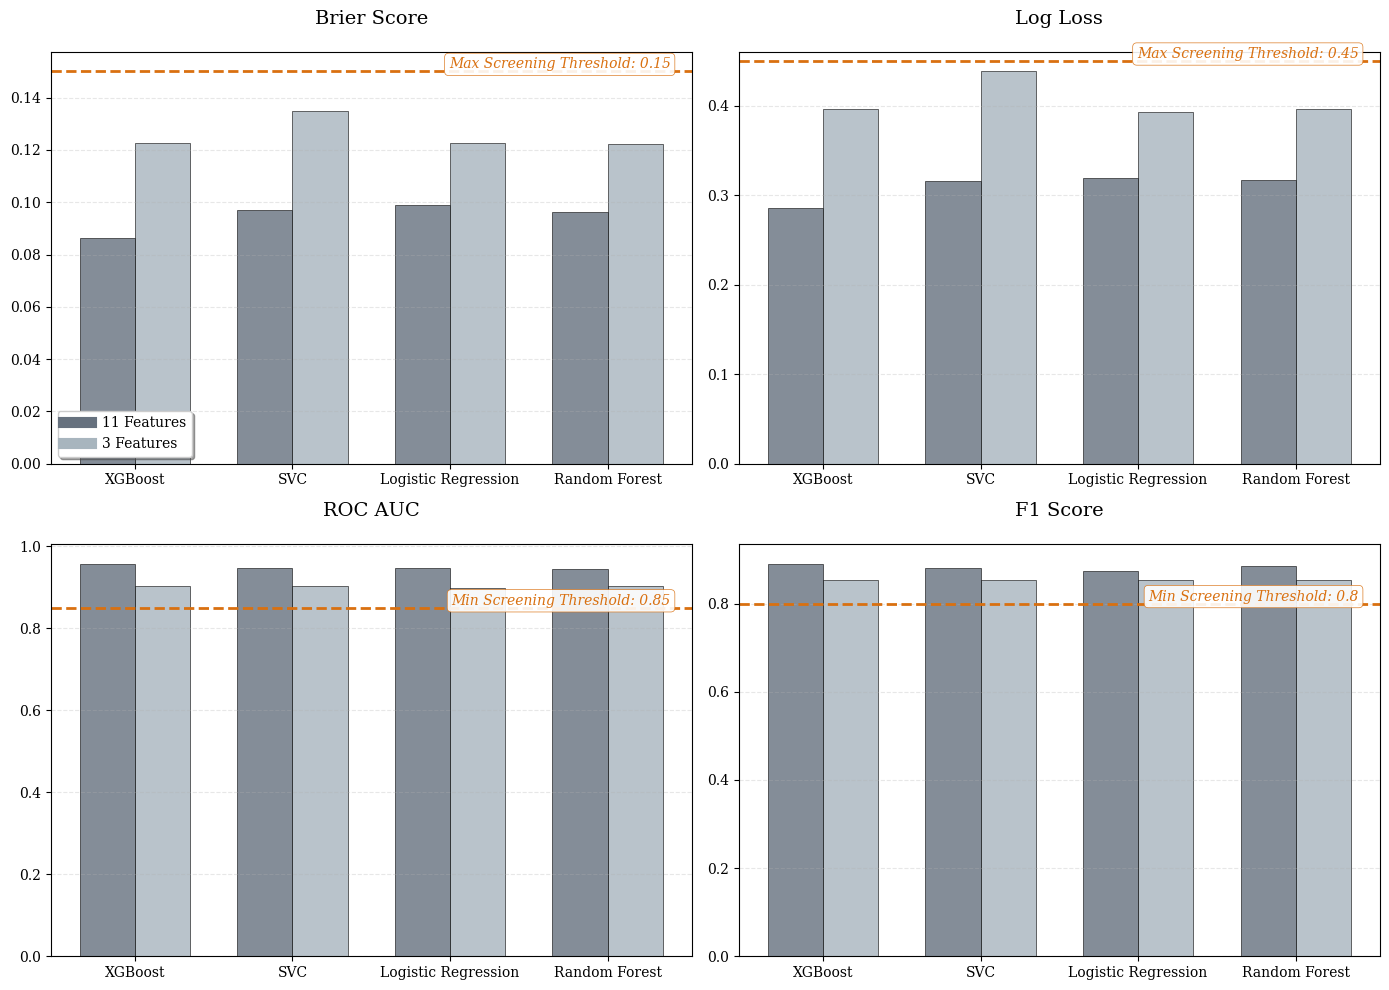

In [24]:
# Defines screening thresholds based on heart disease screening standards
brier_max_ok   = 0.15     
logloss_max_ok = 0.45     
rocauc_min_ok  = 0.85      
f1_min_ok      = 0.80     

# Sets serif font globally to match PowerPoint design aesthetic
plt.rcParams['font.family'] = ['serif']    
plt.rcParams['font.weight'] = 'light'      

base_models = ["XGBoost", "SVC", "Logistic Regression", "Random Forest"]
metrics = ["Brier_Score", "Log_Loss", "ROC_AUC", "F1_Score"]
metric_titles = {
    "Brier_Score": "Brier Score",
    "Log_Loss": "Log Loss",
    "ROC_AUC": "ROC AUC", 
    "F1_Score": "F1 Score"
}

# Builds arrays for plotting
full_vals = {m: [] for m in metrics}   
top3_vals = {m: [] for m in metrics}   

# Extracts metric values for each base model 
for base in base_models:
    row_full = combined_table[combined_table["Model"] == base].iloc[0]
    row_top3 = combined_table[combined_table["Model"] == f"{base} Top 3"].iloc[0]
    for m in metrics:
        full_vals[m].append(row_full[m])     
        top3_vals[m].append(row_top3[m])     

# Defines bar chart positioning
x = np.arange(len(base_models))    
width = 0.35                       

# Selects color to match accent color in ppt
threshold_color = '#D97010'

# Creates 2x2 subplot grid for the four evaluation metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()    

legend_elements = [
    Line2D([0], [0], color="#66717E", lw=8, label="11 Features"), 
    Line2D([0], [0], color="#A8B5BE", lw=8, label="3 Features")   
]

# Plots each metric in its subplot
for i, m in enumerate(metrics):
    ax = axes[i]

    # Creates grayscale bars with one shared legend
    if i == 0:  
        ax.bar(x - width/2, full_vals[m], width, label="11 Features", 
               color="#66717E", alpha=0.8, edgecolor='black', linewidth=0.5)
        ax.bar(x + width/2, top3_vals[m], width, label="3 Features", 
               color="#A8B5BE", alpha=0.8, edgecolor='black', linewidth=0.5)
    else:       
        ax.bar(x - width/2, full_vals[m], width, 
               color="#66717E", alpha=0.8, edgecolor='black', linewidth=0.5)
        ax.bar(x + width/2, top3_vals[m], width, 
               color="#A8B5BE", alpha=0.8, edgecolor='black', linewidth=0.5)

    # Centers x-axis labels for readability
    ax.set_xticks(x)
    ax.set_xticklabels(base_models, rotation=0, ha="center", fontsize=10)

    ax.set_title(metric_titles[m], color='black', fontsize=14, pad=20)

    # Sets threshold label text for each plot
    if m == "Brier_Score":
        thr = brier_max_ok;   label = f"Max Screening Threshold: {thr}"
    elif m == "Log_Loss":
        thr = logloss_max_ok; label = f"Max Screening Threshold: {thr}"
    elif m == "ROC_AUC":
        thr = rocauc_min_ok;  label = f"Min Screening Threshold: {thr}"
    else:  
        thr = f1_min_ok;      label = f"Min Screening Threshold: {thr}"

    # Creates orange threshold line for each plot
    ax.axhline(thr, color=threshold_color, linestyle="dashed", linewidth=2)
    
    # Uses threshold text to label line
    ax.text(x[-1] + 0.4, thr, label, ha="right", va="bottom",
            fontsize=10, fontweight='light', style='italic',
            color=threshold_color,
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', 
                     alpha=0.9, edgecolor=threshold_color, linewidth=0.5))

    # Includes subtle grid for easy value comparison
    ax.grid(axis='y', alpha=0.3, linestyle='--')

# Creates shared legend
axes[0].legend(handles=legend_elements, loc="lower left", 
               frameon=True, fancybox=True, shadow=True)

# Auto-adjusts layout
plt.tight_layout()

# Saves to png for use in ppt
plt.savefig('evaluation_metrics.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show() 

### Feature Importance 

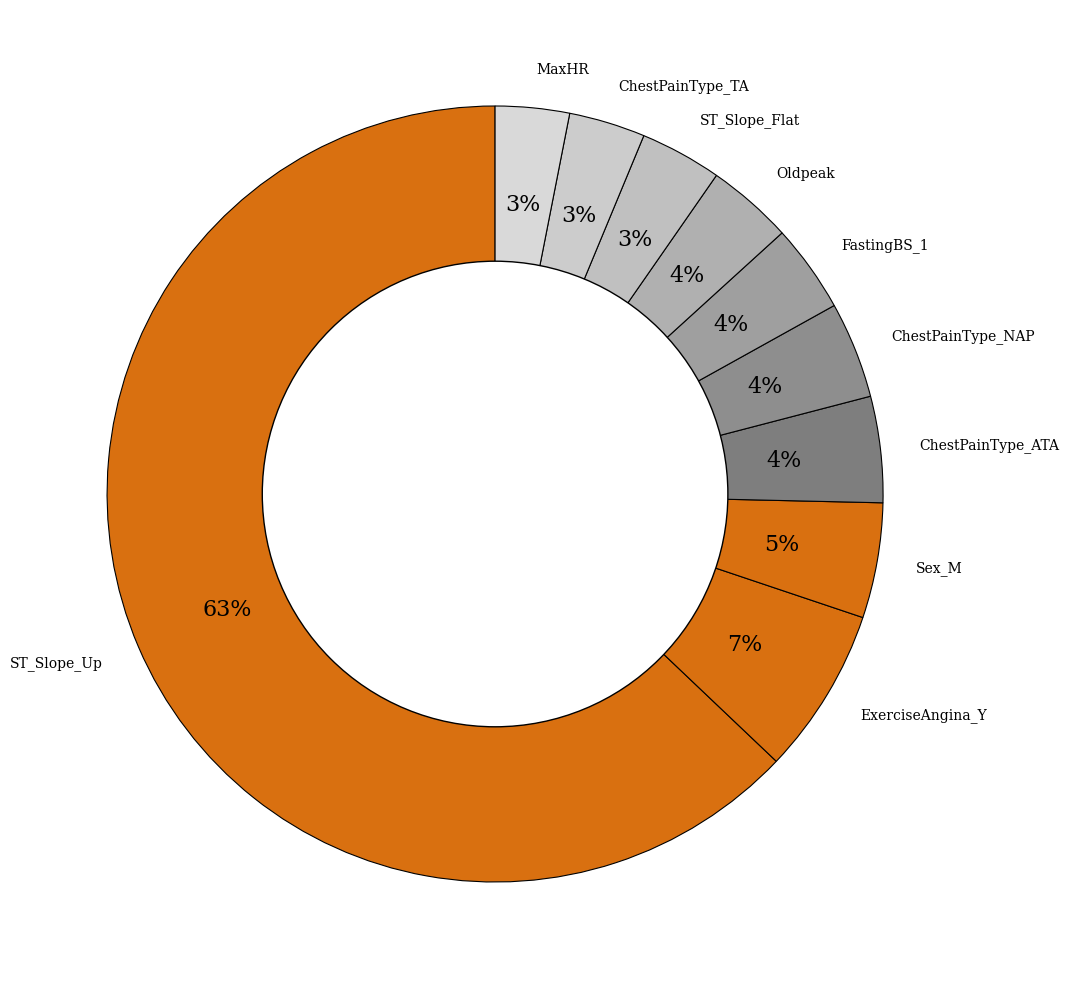

In [25]:
# Keeps with same design theme
plt.rcParams['font.family'] = ['serif']
plt.rcParams['font.weight'] = 'light'

# Extracts top 10 features from XGBoost importance analysis 
top_features = importances_results.head(10).reset_index(drop=True)

# Uses same color to highlight top three features
orange = '#D97010'
top3_features = ['ST_Slope_Up', 'ExerciseAngina_Y', 'Sex_M']  

# Sets lighter grayscale for all other features
gray_gradient = plt.cm.Greys(np.linspace(0.75, 0.25, 10))  

# Assigns chosen colors 
colors = []
for idx in range(len(top_features)):
    feature = top_features.iloc[idx]['feature']
    if feature in top3_features:
        colors.append(orange)      
    else:
        colors.append(gray_gradient[idx])   

# Creates square figure for use with donut
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw=dict(aspect="equal"))

# Generates thick donut chart with corresponding percentage values
wedges, texts, autotexts = ax.pie(top_features['importance'], 
                                  labels=top_features['feature'],
                                  autopct='%1.0f%%',           
                                  startangle=90,               
                                  colors=colors,               
                                  textprops={'fontsize': 10, 'color': 'black'},
                                  pctdistance=0.75,            
                                  wedgeprops=dict(width=0.7,   
                                                 edgecolor='black', 
                                                 linewidth=0.8))

# Creates donut hole with white center circle
centre_circle = Circle((0, 0), 0.60, fc='white', edgecolor='black', linewidth=1)
ax.add_artist(centre_circle)

# Removes title by setting to ""
ax.set_title("")

# Formats percentage labels 
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(16)

plt.tight_layout()
plt.savefig('importances.png', 
            dpi=300, bbox_inches='tight', facecolor='white') 
plt.show()